# Task 3: Customer Churn Prediction

## Introduction

The objective of this project is to predict whether a bank customer is likely to leave the bank based on customer demographics and account information. The project includes data preprocessing, exploratory data analysis, feature encoding, model training, and interpretation of feature importance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


## Data Cleaning

The dataset was inspected for missing values and unnecessary columns. Customer identification columns were removed because they do not contribute to predicting customer churn.

In [9]:
# Check missing values

df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [10]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [11]:
# Remove unnecessary columns

df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Exploratory Data Analysis (EDA)

EDA was performed to understand customer characteristics and identify factors related to customer churn.

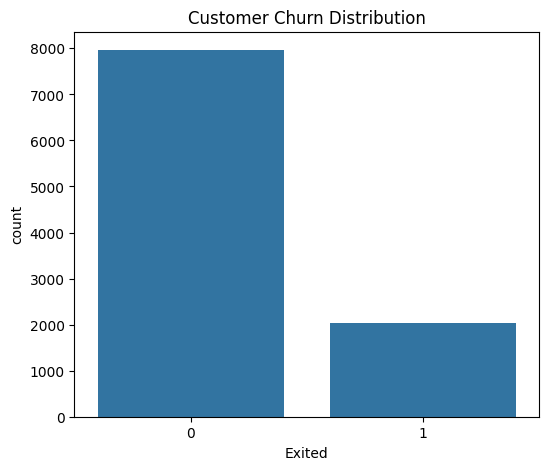

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Exited'
)

plt.title("Customer Churn Distribution")

plt.show()

### Observation

The dataset contains both customers who stayed with the bank and customers who left. The majority of customers did not exit the bank.

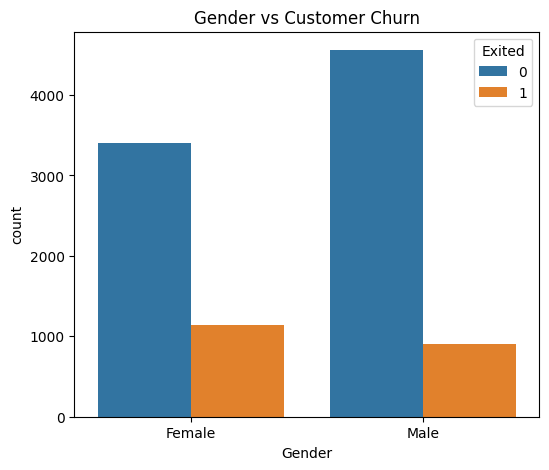

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Exited'
)

plt.title("Gender vs Customer Churn")

plt.show()

### Observation

The visualization compares churn among male and female customers and helps identify whether gender influences customer retention.

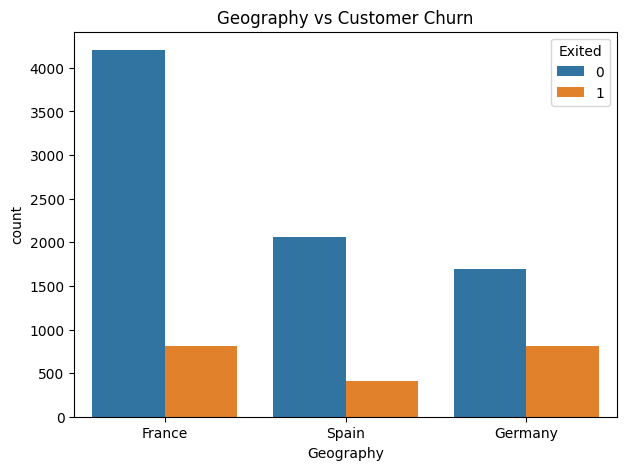

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Geography',
    hue='Exited'
)

plt.title("Geography vs Customer Churn")

plt.show()

### Observation

Customer churn varies across different geographical regions, suggesting that location may influence customer retention.

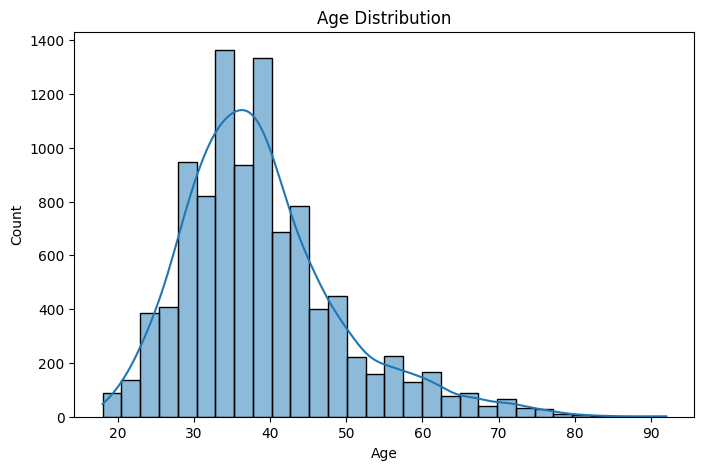

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

### Observation

Most customers are between 30 and 50 years old, with fewer customers in younger and older age groups.

## Feature Encoding

Categorical variables were converted into numerical values using Label Encoding so that they could be used by the machine learning model.

In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])

df['Geography'] = encoder.fit_transform(df['Geography'])

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [17]:
# Separate features and target variable

X = df.drop('Exited', axis=1)

y = df['Exited']

In [18]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8000, 10)
Testing Data: (2000, 10)


## Model Training

A Random Forest Classifier was selected for this classification problem because it provides good predictive performance and allows feature importance analysis.

In [19]:
# Train Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
# Make predictions

y_pred = model.predict(X_test)

## Model Evaluation

The model was evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

In [22]:
# Accuracy Score

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8645


### Model Performance

The Random Forest Classifier achieved an accuracy of **86.45%**, indicating strong performance in predicting whether a customer is likely to leave the bank. This suggests that the model successfully captured important patterns within the dataset.

In [23]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[1546,   61],
       [ 210,  183]])

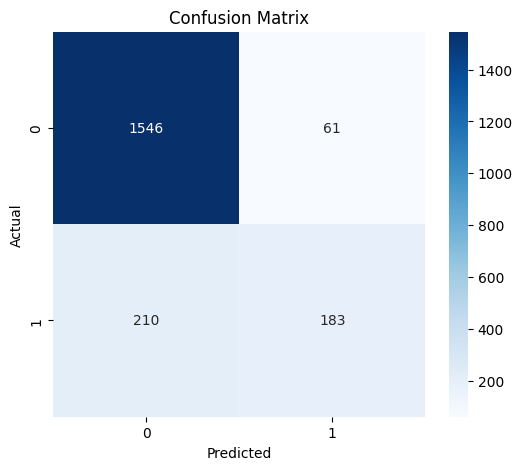

In [24]:
# Confusion Matrix Visualization

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [25]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



## Feature Importance

Feature importance helps identify which customer characteristics have the greatest impact on predicting customer churn.

In [26]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
3,Age,0.240453
9,EstimatedSalary,0.148004
0,CreditScore,0.142369
5,Balance,0.138670
6,NumOfProducts,0.132061
4,Tenure,0.080932
8,IsActiveMember,0.042807
1,Geography,0.037402
2,Gender,0.019032
7,HasCrCard,0.018269


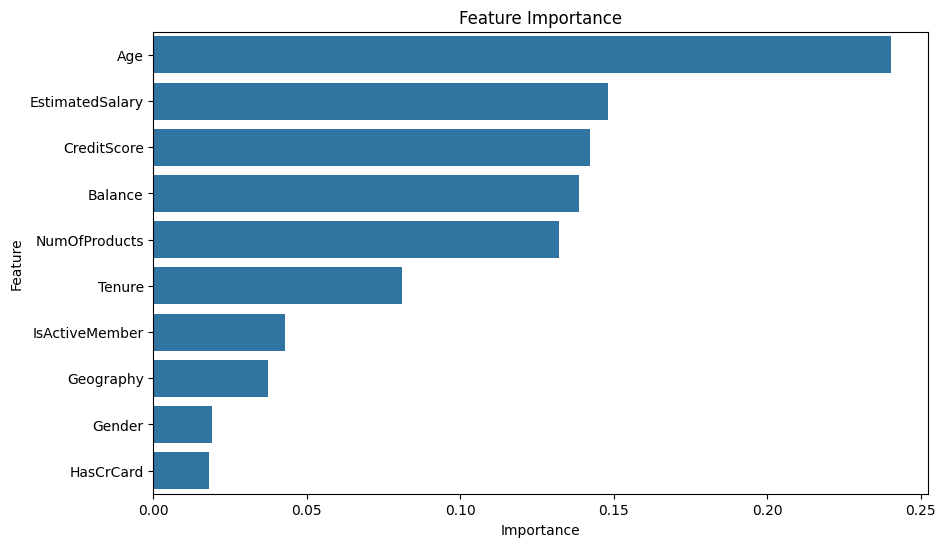

In [27]:
# Feature Importance Visualization

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

### Observation

The feature importance analysis shows that variables such as Age, Balance, Credit Score, and Number of Products have a significant influence on predicting customer churn. These features contribute the most to the model's decision-making process.

## Conclusion

In this project, a Random Forest Classifier was developed to predict customer churn using bank customer data. The dataset was cleaned by removing unnecessary columns and encoding categorical variables. Exploratory Data Analysis (EDA) helped identify patterns in customer behavior. The model achieved good predictive performance, and feature importance analysis highlighted the variables that most strongly influence customer churn. This project demonstrates the practical application of machine learning for customer retention analysis.